# RAG Automotive Reviewer
## Andrew Selius
### CMPS6730

In [1]:
# Necessary installs
%pip install faiss-cpu pandas datasets
%pip install transformers --upgrade
%pip install pandas nltk spacy textblob
%pip install accelerate --upgrade
%pip install sentence-transformers
%pip install sentencepiece
%pip install evaluate
%pip install rouge-score
%pip install bert_score

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Necessary imports

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BartTokenizer, 
    BartForConditionalGeneration, 
    T5Tokenizer,
    T5ForConditionalGeneration,
    TrainingArguments, 
    Trainer,
    TrainerCallback,
    EarlyStoppingCallback)
from sentence_transformers import SentenceTransformer
import re
import os
from datasets import Dataset
import pandas as pd
import numpy as np
import nltk
import faiss
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/andrewselius/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Data Load + Preprocessing

In [3]:
csv_path = "/Users/andrewselius/Documents/GitHub/reviews.csv" # Replace with path as necessary

# Read csv into dataframe, then clean and convert to list
df = pd.read_csv(csv_path)
df.dropna(subset=["brand", "text"], inplace=True)
df["text"] = df["text"].str.strip()
texts = df["text"].tolist()
display(df)

# Create list of brands for tagging
df_brands = df["brand"].unique()
print(df_brands)


,brand,text
0,Honda,"Hondas are generally affordable, reliable, and..."
1,Toyota,Toyota mostly fulfills its reputation for buil...
2,Subaru,Subaru is known for no-nonsense SUVs with stan...
3,Jeep,"The Jeep Wrangler has poor fuel economy, wind ..."
4,BMW,BMW’s sedans and SUVs regularly earn CR’s reco...
...,...,...
95,Mazda,A Japanese car maker founded in 1920 and forma...
96,Tesla,Based in the Silicon Valley area of California...
97,Dodge,Dodge has been around since the early days of ...
98,Ford,"With its updated models and prices, Ford conti..."


['Honda' 'Toyota' 'Subaru' 'Jeep' 'BMW' 'Mazda' 'Tesla' 'Dodge' 'Ford'
 'Chevrolet']


## Text Processing Pipeline
Contains functions for chunking, tagging, embedding, and summarization

In [ ]:
# Chunking function: Creates new dataframe from generated chunks based on model

def chunk(df, model_name, max_tokens=50, overlap=5, prefix_brand=True):
    # Initialize tokenizer and empty list of chunks
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    chunked_data = []

    # Iterate over rows, adding the brand to each chunk to maintain context
    for _, row in df.iterrows():
        brand = row["brand"]
        text = str(row["text"])
        if prefix_brand:
            text = f"{brand}: {text}"

        # Tokenize the full review
        tokens = tokenizer.encode(text, add_special_tokens=False)
        
        # Create overlapping chunks
        for i in range(0, len(tokens), max_tokens - overlap):
            chunk_tokens = tokens[i:i + max_tokens]
            chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)

            chunked_data.append({
                "brand": brand,
                "chunk_text": chunk_text
            })

    chunked_df = pd.DataFrame(chunked_data)
    return chunked_df

In [ ]:
# Chunk original dataframe
df_chunked = chunk(df, model_name="t5-small", max_tokens=50, overlap = 10, prefix_brand=True)

# Check size of new dataframe
print(df_chunked.head())
print(f"Original reviews: {len(df)}, Token-based chunks: {len(df_chunked)}")

# Create list of text chunks for processing
chunked_texts = df_chunked["chunk_text"].tolist()

   brand                                         chunk_text
0  Honda  Honda: Hondas are generally affordable, reliab...
1  Honda  ratings for road tests and predicted reliabili...
2  Honda  it a brand worth considering for options under...
3  Honda  SUVs in North America. The two-row Passport an...
4  Honda  the Odyssey minivan and the Ridgeline, a midsi...
Original reviews: 100, Token-based chunks: 309


### Tagging + Extraction Functions
Brand and topic tags/keywords are assigned to chunks to increase relevant data retrieval. Corresponding brands and topics are extracted from queries.

In [ ]:
# Topic tagging: using the dictionary, classify and tag queries based on presence of keywords

topic_keywords = {
    "reliability": ["reliable", "dependable", "breakdown", "repair", "maintenance"],
    "fuel_efficiency": ["mpg", "fuel", "gas", "mileage", "consumption"],
    "performance": ["engine", "speed", "torque", "acceleration", "handling"],
    "quality": ["luxurious", "comfy", "sturdy", "dynamic", "safe"],
    "comfort": ["seating", "interior", "ride", "suspension", "noise"]
}

# Tagging function for topics
def tag_chunk(chunk_text, topic_keywords):
    matched_topics = []
    lower_text = chunk_text.lower()
    for topic, keywords in topic_keywords.items():
        if any(keyword in lower_text for keyword in keywords):
            matched_topics.append(topic)
    return matched_topics

# Add topics field to chunked dataframe
df_chunked["topics"] = df_chunked["chunk_text"].apply(
    lambda x: tag_chunk(x, topic_keywords)
)
topics = df_chunked["topics"].tolist()

In [ ]:
# Query brand + extraction functions: Determines which brand and relevant topics are present in a query

def extract_brand(query):
    query_lower = query.lower()
    brands = df_chunked["brand"].tolist()
    for brand in brands:
        if brand.lower() in query_lower:
            return brand
    return None

def extract_topics(query):
    query_lower = query.lower()
    matches = []
    for topic, keywords in topic_keywords.items():
        if any(keyword in query_lower for keyword in keywords):
            matches.append(topic)
    return matches

### Embedding Generation and Context Retrieval Functions
Build embeddings for text using faiss index (IP/cosine similarity), then retrieve relevant documents based on brand/topic matches.

In [ ]:

# Embedding function: takes text and model to create embeddings. FAISS index is generated using FlatIP after vector normalization.
# Returns embedder, FAISS index, embeddings
def build_embeddings(texts, model_name):
    embedder = SentenceTransformer(model_name)
    embeddings = embedder.encode(texts, show_progress_bar=True)
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    return embedder, index, embeddings

# Context retrieval function: Takes user query, embedder, index, text, and top_k parameters.
# Returns: top_k relevant documents.
def retrieve_context(query, embedder, index, texts, top_k=5):
    brands = df_chunked["brand"].tolist()

    # Find relevant brand and topics for user query
    detected_brand = extract_brand(query)
    detected_topics = extract_topics(query)

    filtered_entries = []

    # Iterate over chunks, filter to those that match brand and topic tags
    for i, (text, brand, chunk_topics) in enumerate(zip(texts, brands, topics)):
        brand_match = detected_brand is None or brand.lower() == detected_brand.lower()
        topic_match = not detected_topics or any(a in chunk_topics for a in detected_topics)
        if brand_match and topic_match:
            filtered_entries.append((i, text))

    # If the input brand is matched, reconstruct the vectors + indices and retrieve relevant documents, otherwise skip to global search
    if detected_brand:
        print(f"Brand: {detected_brand}")
        
        # Reconstruct filtered index
        filtered_indices, filtered_texts = zip(*filtered_entries)
        filtered_vectors = index.reconstruct_n(filtered_indices[0], len(filtered_indices))

        if not filtered_entries:
            print("No entries for this topic: Trying global search")
        else:
            # Encode query
            query_vec = embedder.encode([query])

            # Build FAISS index for filtered vectors
            faiss.normalize_L2(query_vec)
            filtered_index = faiss.IndexFlatIP(filtered_vectors.shape[1])
            filtered_index.add(np.array(filtered_vectors))
            
            # Create and return list of relevant documents
            _, match_indices = filtered_index.search(np.array(query_vec), top_k)
            matched = [filtered_texts[i] for i in match_indices[0]]
            return " ".join(matched)
    else:
        print("No entries for this brand: Trying global search")


    # Global search for relevant documents if brand/topic match fails

    # Encode query
    query_vec = embedder.encode([query])
    
    # Create and return list of relevant documents
    _, indices = index.search(np.array(query_vec), top_k)
    matched = [texts[i] for i in indices[0]]
    return " ".join(matched)

### Summarizer Functions
Functions to load summarizer from model and create summary from retrieved documents

In [ ]:
# Function to load summarizer from model parameter: Creates tokenizer, model, and summarizer to be returned

def load_summarizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)
    return summarizer


In [ ]:
# Function to generate summary/answer from retrieved documents using the loaded summaraizer

def create_summary(context, summarizer, max_length=120):
    input_text = "summarize: " + context
    result = summarizer(input_text, max_length=max_length, min_length=30, do_sample=False)
    return result[0]["summary_text"]

In [ ]:
# Answer generation function: Combines previous two functions for a single-call process

def generate_answer(query, embedder, index, summarizer, texts, top_k):
    context = retrieve_context(query, embedder, index, texts, top_k = top_k)
    answer = create_summary(context, summarizer)
    return answer

# Evaluation
Includes:
- Evaluation data: test queries, generator models, embeddor models.
- Evaluation metric summarizer: ROUGE and BLEU score calculation and summarization functions.
- Comprehensive evaluation function: Gathers metrics from model-embedder combinations, run against test_set queries.
- Functions to view, interpret, and visualize evaluation results for model and embedder selection.

In [236]:
test_set = [
    {
        "query": "Is Toyota reliable?",
        "reference_summary": "Toyota is often praised for its reliability and long-lasting performance."
    },
    {
        "query": "Does BMW make good performance cars?",
        "reference_summary": "BMW has lost its way in recent years, prioritizing luxury and in-car technology versus satisfying driving characteristics and cars that communicate road feel and handling nuance to their drivers."
    },
    {
        "query": "Are Honda cars fuel efficient?",
        "reference_summary": "Hondas are generally affordable, reliable, and fuel-efficient, with intuitive controls and good driving characteristics."
    }
    
]

In [ ]:
generator_models = [
    "t5-small",
    "t5-base",
    "facebook/bart-large-cnn"
]

embedder_models = [
    "all-MiniLM-L6-v2",
    "multi-qa-MiniLM-L6-cos-v1",
    "all-mpnet-base-v2"
]

In [ ]:
# Function to summarize evaluations. Returns dict of ROUGE and BLEU scores for model-embedder pair.

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

# Initialize ROUGE scorer and smoothing function
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method4

def evaluate_summary(predicted: str, reference: str):
    # ROUGE scores
    rouge_scores = rouge.score(reference, predicted)

    # BLEU score
    reference_tokens = [word_tokenize(reference.lower())]
    predicted_tokens = word_tokenize(predicted.lower())
    bleu_score = sentence_bleu(reference_tokens, predicted_tokens, smoothing_function=smoother)

    # Create dictionary of ROUGE and BLEU scores. Note that ROUGE scores are F1-score based in this context.
    return {
        "rouge-1": rouge_scores["rouge1"].fmeasure,
        "rouge-2": rouge_scores["rouge2"].fmeasure,
        "rouge-L": rouge_scores["rougeL"].fmeasure,
        "bleu": bleu_score
    }

In [ ]:
# Comprehensive evaluation of model-embedder combinations against test_set queries

results = []

for model_name in generator_models:
    summarizer = load_summarizer(model_name)

    for embedder_name in embedder_models:
        print(f"\nEvaluating model: {model_name}")
        print(f"\nWith embedder: {embedder_name}")
        embedder, index, _ = build_embeddings(chunked_texts, embedder_name)
        
        # Given model-embedder pair, evaluate against each test query-reference pair
        for entry in test_set:
            question = entry["query"]
            reference = entry["reference_summary"]
            context = retrieve_context(question, embedder, index, chunked_texts)
            prediction = create_summary(context, summarizer)
            scores = evaluate_summary(prediction, reference)

            # Add results to results dictionary
            results.append({
                "model": model_name,
                "embedder": embedder_name,
                "question": question,
                "ref_summary": reference,
                "prediction": prediction,
                **scores
            })

Device set to use mps:0



Evaluating model: t5-small

With embedder: all-MiniLM-L6-v2


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Brand: Toyota
Brand: BMW
Brand: Honda

Evaluating model: t5-small

With embedder: multi-qa-MiniLM-L6-cos-v1


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

...

Brand: Toyota
Brand: BMW
Brand: Honda

Evaluating model: facebook/bart-large-cnn

With embedder: multi-qa-MiniLM-L6-cos-v1


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Brand: Toyota
Brand: BMW
Brand: Honda

Evaluating model: facebook/bart-large-cnn

With embedder: all-mpnet-base-v2


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Brand: Toyota
Brand: BMW
Brand: Honda


In [ ]:
# Display evaluation results as a dataframe

eval_df = pd.DataFrame(results)
eval_df[["model", "embedder", "question", "rouge-1", "rouge-2", "rouge-L", "bleu"]]

,model,embedder,question,rouge-1,rouge-2,rouge-L,bleu
0,t5-small,all-MiniLM-L6-v2,Is Toyota reliable?,0.076923,0.000000,0.038462,0.009371
1,t5-small,all-MiniLM-L6-v2,Does BMW make good performance cars?,0.119403,0.000000,0.119403,0.010796
2,t5-small,all-MiniLM-L6-v2,Are Honda cars fuel efficient?,0.166667,0.000000,0.125000,0.013151
3,t5-small,multi-qa-MiniLM-L6-cos-v1,Is Toyota reliable?,0.090909,0.000000,0.045455,0.011564
4,t5-small,multi-qa-MiniLM-L6-cos-v1,Does BMW make good performance cars?,0.119403,0.000000,0.119403,0.010564
5,t5-small,multi-qa-MiniLM-L6-cos-v1,Are Honda cars fuel efficient?,0.625000,0.608696,0.625000,0.491678
6,t5-small,all-mpnet-base-v2,Is Toyota reliable?,0.200000,0.000000,0.100000,0.014554
7,t5-small,all-mpnet-base-v2,Does BMW make good performance cars?,0.149254,0.000000,0.119403,0.010713
8,t5-small,all-mpnet-base-v2,Are Honda cars fuel efficient?,0.163265,0.000000,0.122449,0.011691
9,t5-base,all-MiniLM-L6-v2,Is Toyota reliable?,0.140351,0.000000,0.140351,0.009554


In [ ]:
# Average metrics by model, embedder

avg_metrics = eval_df.groupby("model")[["rouge-1", "rouge-2", "rouge-L", "bleu"]].mean().reset_index()
avg_metrics_e = eval_df.groupby("embedder")[["rouge-1", "rouge-2", "rouge-L", "bleu"]].mean().reset_index()
print("Average Evaluation Metrics:")
display(avg_metrics)
display(avg_metrics_e)

Average Evaluation Metrics:
                     model   rouge-1   rouge-2   rouge-L      bleu
0  facebook/bart-large-cnn  0.162030  0.004274  0.124309  0.010736
1                  t5-base  0.134318  0.003899  0.120151  0.011334
2                 t5-small  0.190092  0.067633  0.157175  0.064898


In [ ]:
# Sorting evaluation results to find top overall model-embedder pair.

eval_df_sorted = eval_df.sort_values(by = 'rouge-L', ascending=False).reset_index()
eval_df_sorted[["model", "embedder", "rouge-L"]].head()

,model,embedder,rouge-L
0,t5-small,multi-qa-MiniLM-L6-cos-v1,0.625000
1,t5-base,all-mpnet-base-v2,0.169492
2,facebook/bart-large-cnn,multi-qa-MiniLM-L6-cos-v1,0.148148
3,t5-base,all-MiniLM-L6-v2,0.145455
4,t5-base,all-MiniLM-L6-v2,0.140351


## Evaluation Visualizations

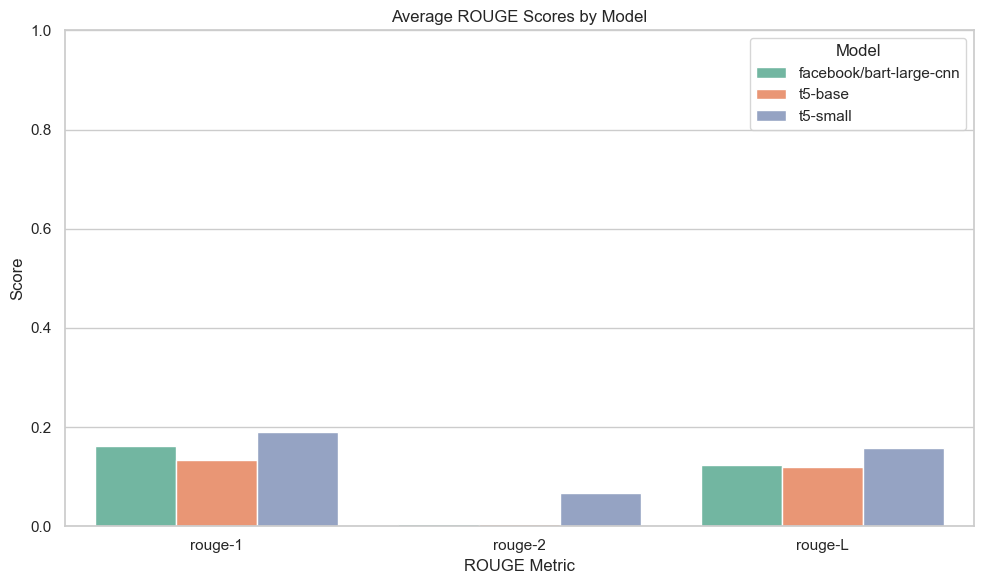

In [ ]:
# Visualizations for scores by model, embedder

import matplotlib.pyplot as plt
import seaborn as sns

avg_melted_m = avg_metrics.melt(id_vars="model", var_name="metric", value_name="score")
rouge_metrics = avg_melted_m[avg_melted_m["metric"].str.contains("rouge")]
bleu_metrics = avg_melted_m[avg_melted_m["metric"] == "bleu"]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=rouge_metrics, x="metric", y="score", hue="model", palette="Set2")
plt.title("Average ROUGE Scores by Model")
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.xlabel("ROUGE Metric")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

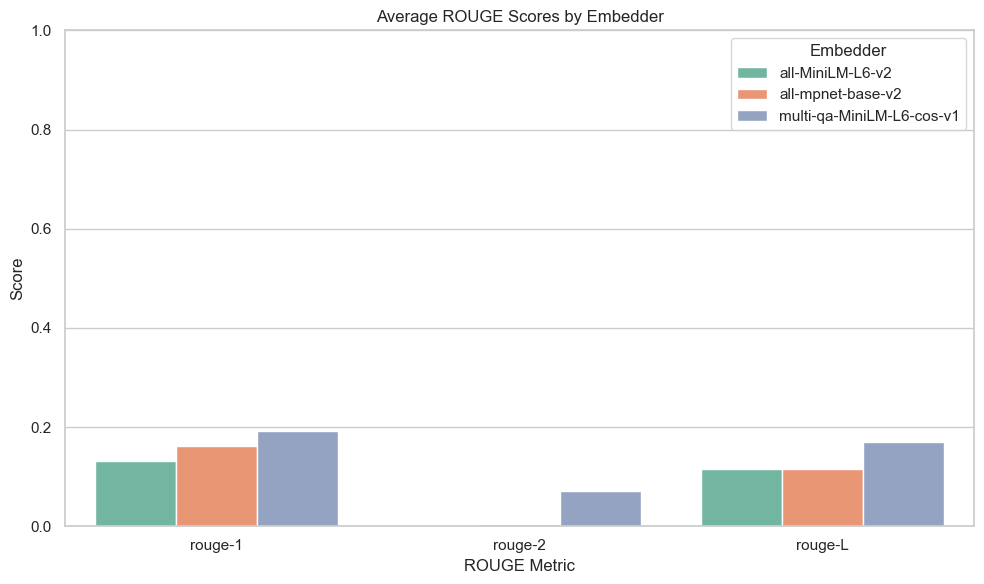

In [255]:
avg_melted_e = avg_metrics_e.melt(id_vars="embedder", var_name="metric", value_name="score")
rouge_metrics_e = avg_melted_e[avg_melted_e["metric"].str.contains("rouge")]
bleu_metrics_e = avg_melted_e[avg_melted_e["metric"] == "bleu"]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=rouge_metrics_e, x="metric", y="score", hue="embedder", palette="Set2")
plt.title("Average ROUGE Scores by Embedder")
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.xlabel("ROUGE Metric")
plt.legend(title="Embedder")
plt.tight_layout()
plt.show()

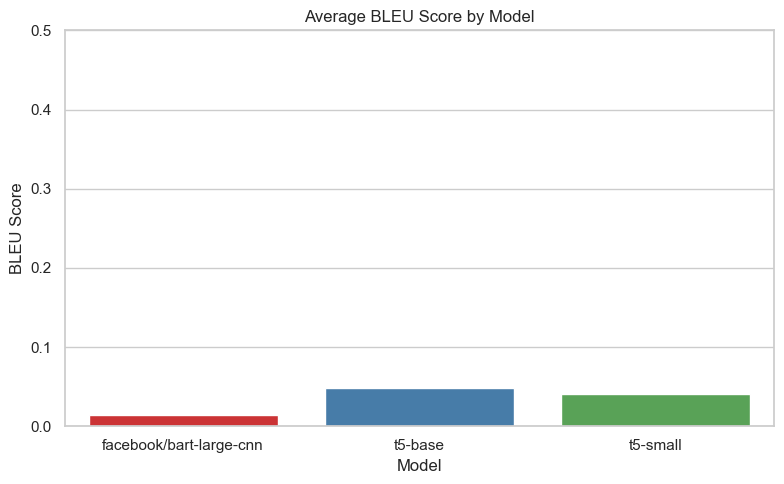

In [243]:
plt.figure(figsize=(8, 5))
sns.barplot(data=bleu_metrics, x="model", y="score", palette="Set1")
plt.title("Average BLEU Score by Model")
plt.ylim(0, 0.5)
plt.ylabel("BLEU Score")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

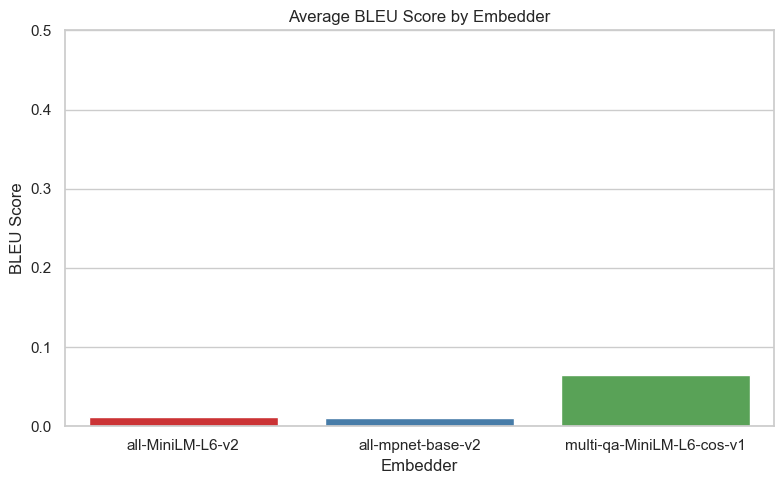

In [256]:
plt.figure(figsize=(8, 5))
sns.barplot(data=bleu_metrics_e, x="embedder", y="score", palette="Set1")
plt.title("Average BLEU Score by Embedder")
plt.ylim(0, 0.5)
plt.ylabel("BLEU Score")
plt.xlabel("Embedder")
plt.tight_layout()
plt.show()

# Test Queries

In [279]:
model_name_test = "t5-small"	
embedder_name_test = "multi-qa-MiniLM-L6-cos-v1"
#embedder_name_test = "all-MiniLM-L6-v2"
summarizer = load_summarizer(model_name_test)
embedder, index, _ = build_embeddings(chunked_texts, embedder_name_test)




Device set to use mps:0


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
query = "How reliable is BMW?"

answer = generate_answer(query, embedder, index, summarizer, chunked_texts, top_k=5)

print("\nAnswer:\n", answer)

# Chat Function

In [288]:
def chat():
    print("Auto Review Summarizer\nType 'exit' to quit.\n")

    while True:
        print("Available brands to ask about: Honda, Toyota, Subaru, Jeep, BMW, Mazda, Tesla, Dodge, Ford, Chevrolet")
        user_input = input("Ask about a car brand (e.g., 'Is Honda reliable?'): ").strip()
        print(f"\nUser: {user_input}\n")
        if user_input.lower() in ["exit", "quit"]:
            print("Goodbye!")
            break

        response = generate_answer(user_input, embedder, index, summarizer, chunked_texts, top_k=7)
        print(f"\nSummary:\n{response}\n")

In [289]:
if __name__ == "__main__":
    chat()

Auto Review Summarizer
Type 'exit' to quit.

Available brands to ask about: Honda, Toyota, Subaru, Jeep, BMW, Mazda, Tesla, Dodge, Ford, Chevrolet

User: Is Honda reliable?

Brand: Honda

Summary:
Hondas are generally affordable, reliable, and fuel-efficient, with intuitive controls and good driving characteristics . it still offers traditional cars and the Odyssey minivan, but the emphasis is clearly in Honda .

Available brands to ask about: Honda, Toyota, Subaru, Jeep, BMW, Mazda, Tesla, Dodge, Ford, Chevrolet

User: Does Subaru make sporty cars?

Brand: Subaru

Summary:
a long-standing criticism of Subaru has revolved around the underpowered engines it uses to propel many of its vehicles . the outback's 2.5-liter naturally aspirated boxer base engine . a 2.4-liter turbocharged boxer-four made a healthy 260 horsepower and 270 lb- powertrain .

Available brands to ask about: Honda, Toyota, Subaru, Jeep, BMW, Mazda, Tesla, Dodge, Ford, Chevrolet

User: quit

Goodbye!
